# Continuous Patient Monitoring with AI: Real-Time Analysis of Video in Hospital Care Settings

> This is a companion notebook to the following project: [link](https://lookdeep.github.io/ai-norms-2024/)



## Welcome!

You are likely here because you read the titled manuscript and are looking for the public data and associated code that was mentioned.

Thank you for your interest in analyzing these anonymized computer vision predictions, aggregated at the patient-day-hour level. We invite you to explore the trends reported in the manuscript (and more), and provide the materials below as support.

### About

This notebook is about a new, fully anonymized dataset (unnamed). This data consists of computer vision predictions recorded from hundreds of patients over a 6-month period, aggregated at the patient-day-hour level.

### Citation

If you would like to reference this work, please use:

```bibtex
@misc{gabriel2024continuouspatientmonitoringai,
      title={Continuous Patient Monitoring with AI: Real-Time Analysis of Video in Hospital Care Settings},
      author={Paolo Gabriel and Peter Rehani and Tyler Troy and Tiffany Wyatt and Michael Choma and Narinder Singh},
      year={2024},
      eprint={2412.13152},
      archivePrefix={arXiv},
      primaryClass={cs.CV},
      url={https://arxiv.org/abs/2412.13152},
}
```

## Download Data

The dataset is publically accessible through github at the following link:
```
https://raw.githubusercontent.com/lookdeep/ai-norms-2024/refs/heads/main/data/data_by_patient_hour_scrubbed.csv
```

It can be downloaded using the `pandas` library.

In [ ]:
import pandas as pd

url_data = "https://raw.githubusercontent.com/lookdeep/ai-norms-2024/refs/heads/main/data/data_by_patient_hour_scrubbed.csv"

df_data = pd.read_csv(url_data)


In [ ]:
df_data.head()

,model_name,day_loc,hour_loc,num_samples,percent_alone,count_fence_crossed,percent_fence_crossed,percent_bed_active,percent_scene_active,count_alone_active,...,monitor_id,group_ADC,gender,group_age,ts,division_name,timestamp_shift,timestamp_plot,hour_loc_shift,tod_loc_shift
0,Model v5,3,17,3600,98.5833,140,3.8889,0.0,3.7500,85,...,3584,150+,male,65-84,2000-03-24 17:00:00.748000+00:00,Hospital 1,2000-03-24 20:00:00.748000+00:00,83 days 20:00:00.748000,20,True
1,Model v5,1,18,3600,86.2500,793,22.0278,0.0,3.4167,89,...,3584,150+,male,65-84,2000-03-22 18:00:00.741000+00:00,Hospital 1,2000-03-22 21:00:00.741000+00:00,81 days 21:00:00.741000,21,True
2,Model v5,3,7,3600,94.8333,761,21.1389,0.0,16.9722,454,...,3584,150+,male,65-84,2000-03-25 07:00:00.737000+00:00,Hospital 1,2000-03-25 10:00:00.737000+00:00,84 days 10:00:00.737000,10,True
3,Model v5,2,18,3600,99.9722,29,0.8056,0.0,1.0000,35,...,3584,150+,male,65-84,2000-03-23 18:00:00.723000+00:00,Hospital 1,2000-03-23 21:00:00.723000+00:00,82 days 21:00:00.723000,21,True
4,Model v5,3,13,3600,100.0000,15,0.4167,0.0,0.0000,0,...,3584,150+,male,65-84,2000-03-24 13:00:00.745000+00:00,Hospital 1,2000-03-24 16:00:00.745000+00:00,83 days 16:00:00.745000,16,True


## Dataset Features
These trends provide hour-over-hour insight into various patient behvaiors and room conditions, including but not limited to:

```
**Metadata:**
- model_name
- day_loc
- hour_loc
- monitor_id
- division_name
- group_ADC
- gender
- group_age
- ts

**Data:**
- num_samples
- percent_alone
- count_fence_crossed
- percent_fence_crossed
- percent_bed_active
- percent_scene_active
- count_alone_active
- percent_alone_active
- count_alone_fence_crossed
- percent_alone_fence_crossed
- percent_staff
- percent_supervized
- percent_supervized_staff
- percent_supervized_other
- percent_supervized_staff_fence_crossed
```


### Real example

In [ ]:
df_data.iloc[0].to_dict()

{'model_name': 'Model v5',
 'day_loc': 3,
 'hour_loc': 17,
 'num_samples': 3600,
 'percent_alone': 98.5833,
 'count_fence_crossed': 140,
 'percent_fence_crossed': 3.8889,
 'percent_bed_active': 0.0,
 'percent_scene_active': 3.75,
 'count_alone_active': 85,
 'percent_alone_active': 2.3611,
 'count_alone_fence_crossed': 96,
 'percent_alone_fence_crossed': 2.6667,
 'percent_staff': 2.1389,
 'percent_supervized': 1.4167,
 'percent_supervized_staff': 0.9444,
 'percent_supervized_other': 1.0556,
 'percent_supervized_staff_fence_crossed': 0.8333,
 'monitor_id': 3584,
 'group_ADC': '150+',
 'gender': 'male',
 'group_age': '65-84',
 'ts': '2000-03-24 17:00:00.748000+00:00',
 'division_name': 'Hospital 1'}

## Plots

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
import seaborn as sns
import pandas as pd


sns.set_style("whitegrid")
sns.set_context('poster')


In [ ]:
# plot-specific pre-calculations

## shift timestamps for plotting
df_data['timestamp_shift'] = pd.to_datetime(df_data['ts'].values, format="mixed") + pd.Timedelta(3, 'h') # so start is 9pm
df_data['timestamp_plot'] = df_data['timestamp_shift'] - df_data['timestamp_shift'].min().floor(freq='d')
df_data['hour_loc_shift'] = df_data['timestamp_shift'].map(lambda x: x.hour)
df_data['tod_loc_shift'] = df_data['hour_loc_shift'].apply(lambda x: int(x) > 9) # 9pm - 6am is False aka nighttime

## create separate dataframe with groupings
df_summary_agg = pd.DataFrame([k+(v,) for k, v in df_data.groupby(['monitor_id', 'division_name', 'group_ADC', 'group_age', 'gender', 'model_name'])['day_loc'].nunique().to_dict().items()], columns=['monitor_id', 'division_name', 'group_ADC', 'group_age', 'gender', 'model_name', 'duration']).sort_values('duration').reset_index()



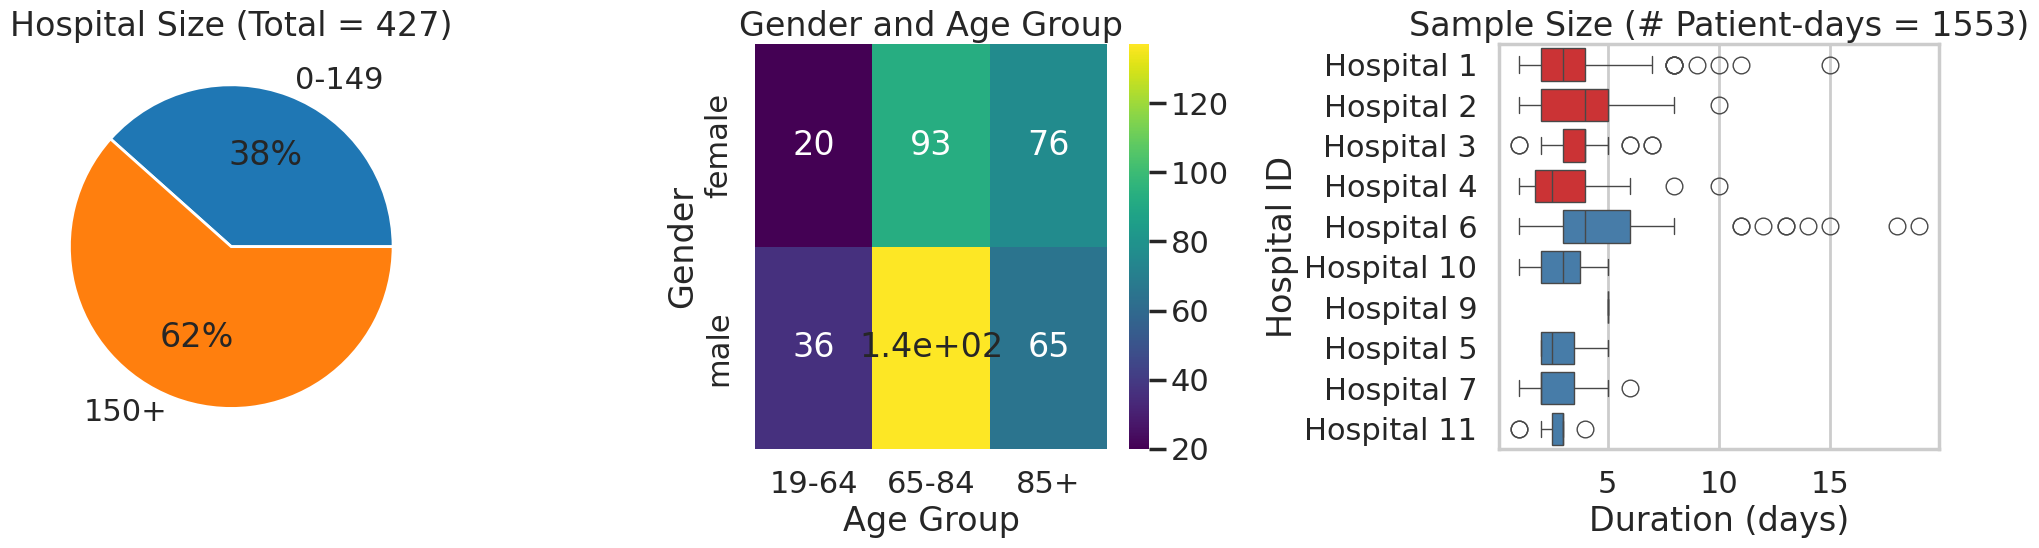

In [ ]:
# @title division_name

fig, axs = plt.subplots(1,3, figsize=(20,6))

ax = axs[0]
df_summary_agg.groupby('group_ADC').size().plot(kind='pie', autopct='%.0f%%', ax=ax)
ax.set_title(f"Hospital Size (Total = {len(df_summary_agg)})")

ax = axs[1]
df_2dhist = pd.DataFrame({
    x_label: grp['gender'].value_counts()
    for x_label, grp in df_summary_agg.groupby('group_age')
})
sns.heatmap(df_2dhist, cmap='viridis', annot=True, ax=ax)
ax.set_xlabel('Age Group')
ax.set_ylabel('Gender')
ax.set_title('Gender and Age Group')

ax = axs[2]
sns.boxplot(data=df_summary_agg.sort_values('group_ADC', ascending=False), x='duration', y='division_name', hue='group_ADC', palette='Set1', ax=ax)
ax.set_title(f"Sample Size (# Patient-days = {df_summary_agg['duration'].sum().astype(int)})")
ax.get_legend().remove()
ax.set_ylabel("Hospital ID")
ax.set_xlabel("Duration (days)")

plt.tight_layout()


<ipython-input-11-ac61fbe8ec70>:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


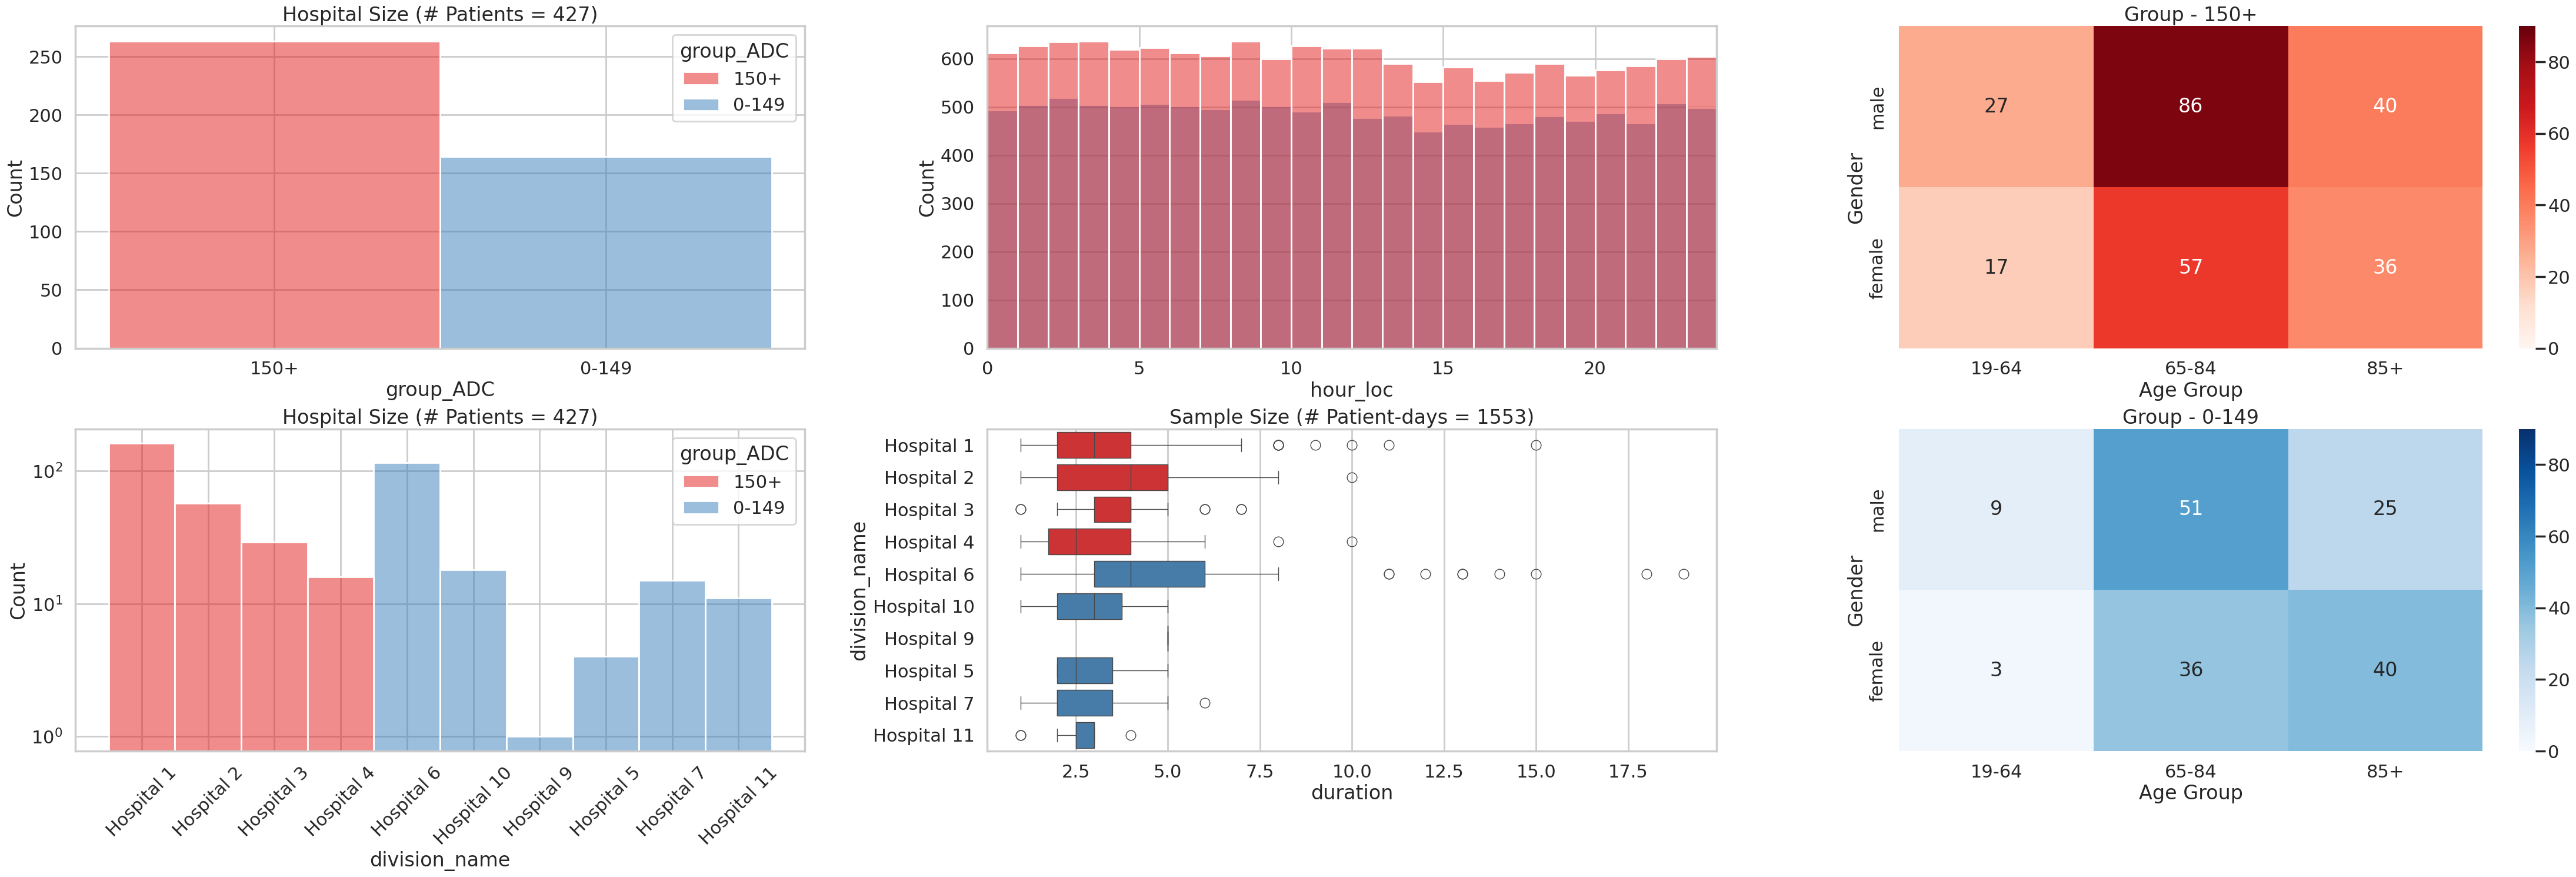

In [ ]:
# @title division_name

fig = plt.figure(figsize=(56,16), facecolor='w')
gs = GridSpec(2, 3, wspace=0.25, hspace=0.25,) # 2x3 grid

ax = fig.add_subplot(gs[0,0])
# df_summary_agg.groupby('group_ADC').size().plot(kind='pie', autopct='%.0f%%', colors=sns.color_palette('Set2'), ax=ax)
sns.histplot(data=df_summary_agg.sort_values('group_ADC', ascending=False), x='group_ADC', hue='group_ADC', palette='Set1', ax=ax)
ax.set_title(f"Hospital Size (# Patients = {len(df_summary_agg)})")

ax = fig.add_subplot(gs[1,0])
sns.histplot(data=df_summary_agg.sort_values('group_ADC', ascending=False), x='division_name', hue='group_ADC', palette='Set1', ax=ax)
ax.tick_params(axis='x', labelrotation=45)
ax.set_title(f"Hospital Size (# Patients = {len(df_summary_agg)})")
ax.set_yscale('log')

ax = fig.add_subplot(gs[0,1])
sns.histplot(data=df_data.sort_values('group_ADC', ascending=False), x='hour_loc', kde=False, bins=np.arange(0,25,1), hue='group_ADC', palette='Set1',ax=ax)
ax.set_xlim(0,24)
ax.get_legend().remove()

ax = fig.add_subplot(gs[1,1])
sns.boxplot(data=df_summary_agg.sort_values('group_ADC', ascending=False), x='duration', y='division_name', hue='group_ADC', palette='Set1', ax=ax)
ax.set_title(f"Sample Size (# Patient-days = {df_summary_agg['duration'].sum()})")
ax.get_legend().remove()

ax = fig.add_subplot(gs[0,2])
df_2dhist = pd.DataFrame({
    x_label: grp['gender'].value_counts()
    for x_label, grp in df_summary_agg[df_summary_agg['group_ADC']=='150+'].groupby('group_age')
})
sns.heatmap(df_2dhist.sort_values('gender', ascending=False), cmap='Reds', annot=True, fmt='.0f', ax=ax, vmax=90, vmin=0)
ax.set_xlabel('Age Group')
ax.set_ylabel('Gender')
ax.set_title('Group - 150+')

ax = fig.add_subplot(gs[1,2])
df_2dhist = pd.DataFrame({
    x_label: grp['gender'].value_counts()
    for x_label, grp in df_summary_agg[df_summary_agg['group_ADC']=='0-149'].groupby('group_age')
})
sns.heatmap(df_2dhist.sort_values('gender', ascending=False), cmap='Blues', annot=True, fmt='.0f', ax=ax, vmax=90, vmin=0)
ax.set_xlabel('Age Group')
ax.set_ylabel('Gender')
ax.set_title('Group - 0-149')

plt.tight_layout()


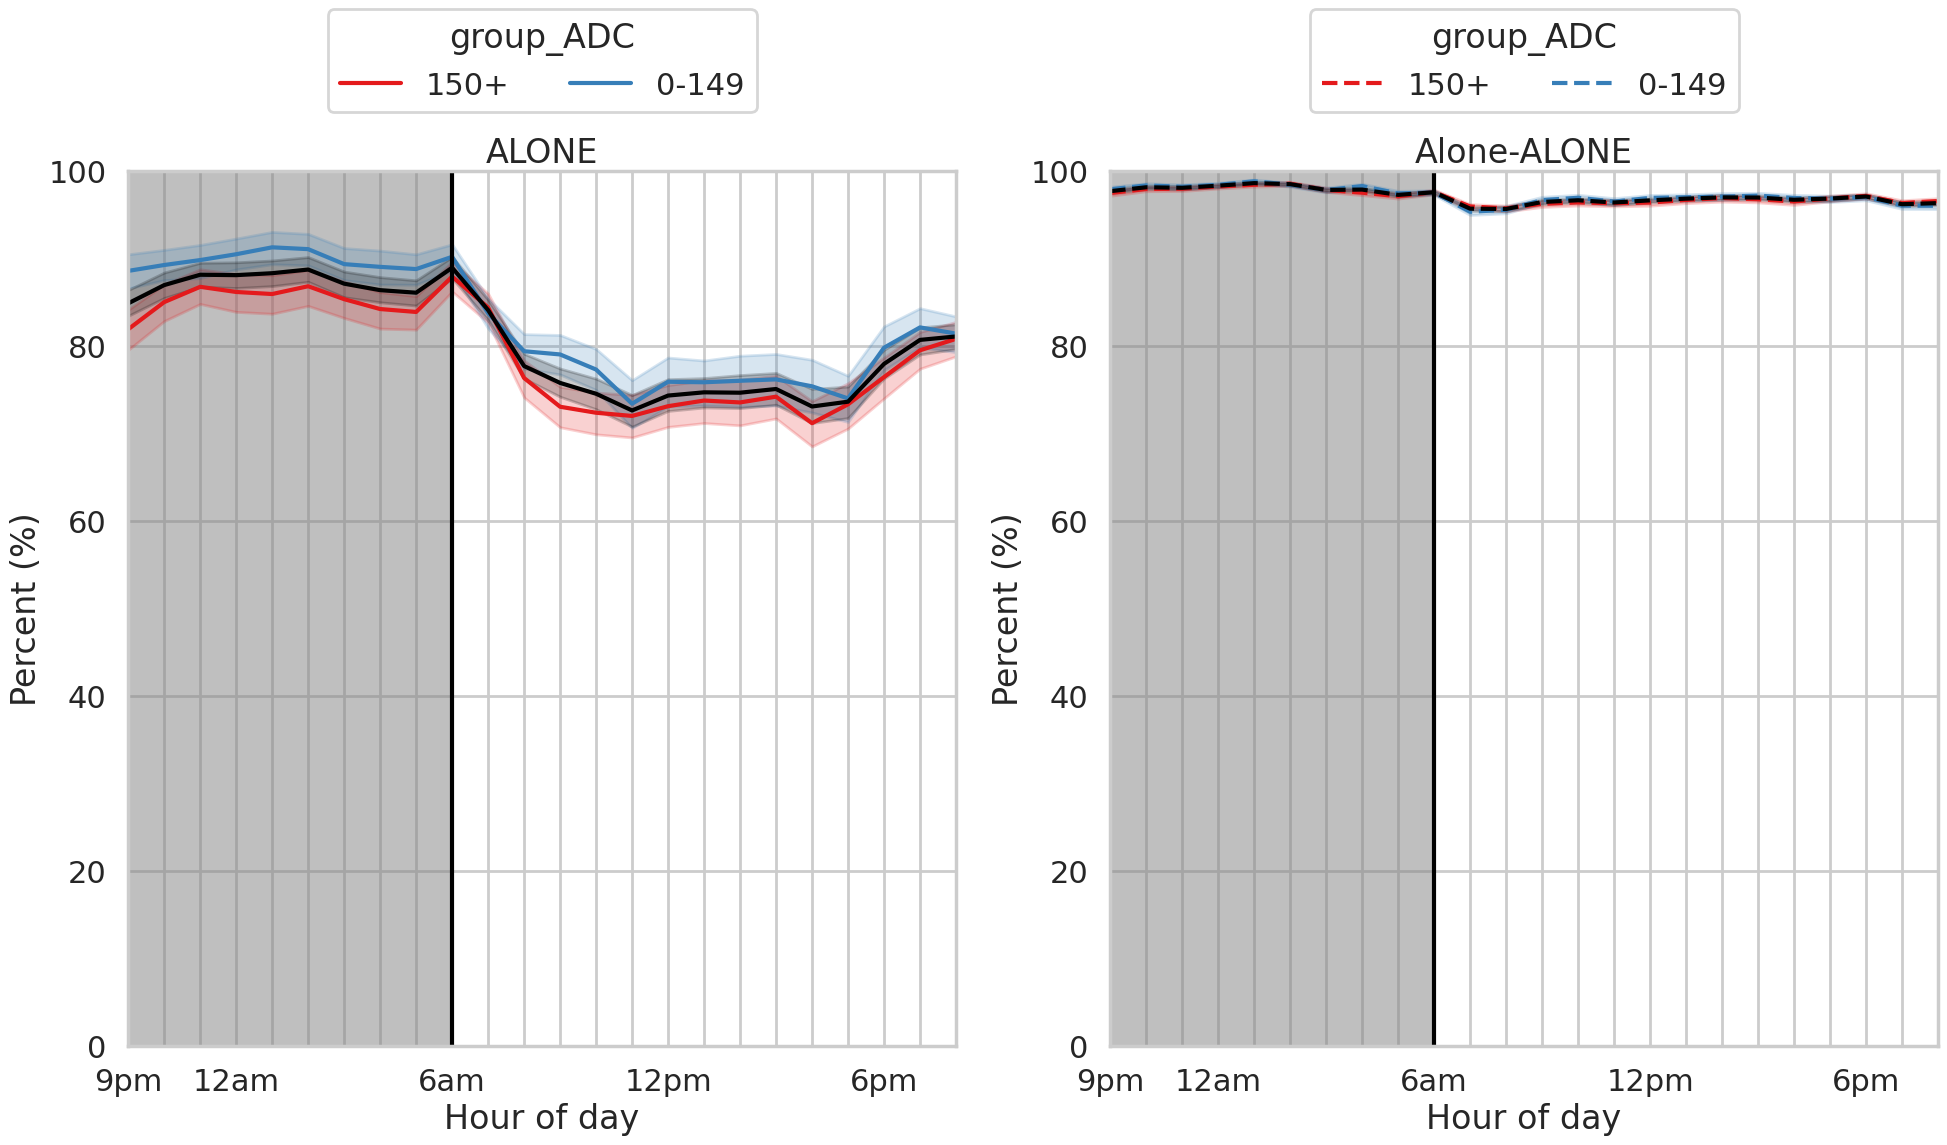

In [ ]:
# @title plot explosion
hues = ['group_ADC', 'group_age', 'model_name']
features = [
    'percent_alone',
    'percent_scene_active',
    'percent_fence_crossed',
    'percent_staff',
    'percent_alone_active',
    'percent_alone_fence_crossed',
    'percent_supervized_staff'
]

for idx, h in enumerate(hues, start=1):
  for y in features:

    df = df_data[df_data['percent_alone'] > 90].sort_values('group_ADC', ascending=False)
    ymin = min(df[y].min(), df_data[y].min())
    ymax = max(df[y].max(), df_data[y].max())

    fig, axs = plt.subplots(1,2, figsize=(20,12))

    ax = axs[0]
    ax.add_patch(Rectangle((0, ymin-0.5), 9, ymax+0.5, alpha=0.5, facecolor = 'grey', fill=True,))

    sns.lineplot(data=df_data.sort_values('group_ADC', ascending=False), x='hour_loc_shift', y=y, hue=h, ax=ax, palette=f"Set{idx}")
    sns.lineplot(data=df_data.sort_values('group_ADC', ascending=False), x='hour_loc_shift', y=y, color='k', ax=ax)

    ax.set_title(f"{y.split('percent_')[1].upper()}")

    ax = axs[1]
    ax.add_patch(Rectangle((0, ymin-0.5), 9, ymax+0.5, alpha=0.5, facecolor = 'grey', fill=True,))

    sns.lineplot(data=df, x='hour_loc_shift', y=y, hue=h, ax=ax, linestyle='--', palette=f"Set{idx}")
    sns.lineplot(data=df, x='hour_loc_shift', y=y, color='k', ax=ax, linestyle='--',)

    ax.set_title(f"Alone-{y.split('percent_')[1].upper()}")

    for ax in axs.tolist():
      ax.set_ylabel("Percent (%)")
      ax.set_xlabel("Local Hour")
      ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.05),
              ncol=3, title=f"{h}")

      ax.set_xticks([0, 3, 9, 15, 21, 24])
      ax.set_xticklabels(['9pm', '12am', '6am', '12pm', '6pm', '|]'])
      ax.xaxis.set_minor_locator(MultipleLocator(1))
      ax.set_xlabel("Hour of day")
      ax.axvline(9, color='k')
      ax.grid(True, which='both')

      ax.set_ylim(ymin, ymax)
      ax.set_xlim(0,23)
    plt.tight_layout()

    break
  break